# MLP Stock Prediction

This notebook builds a simple multi-layer perceptron to predict the next-day daily return for one stock from the repository dataset.

## 1. Imports

Import the libraries and helpers used throughout the notebook.

In [9]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from tradinglab.data_feed import DataFeed
from tradinglab.features import build_dataset
from tradinglab.models import DeepMLP

torch.manual_seed(0)
np.random.seed(0)
plt.style.use('seaborn-v0_8')

## 2. Load Data

Load one stock from the EGX dataset and inspect its basic properties.

In [10]:
symbol = 'ABUK'

# Resolve the repository root dynamically so the notebook works from VS Code or the terminal.
repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'data' / 'egx').exists() and (candidate / 'src').exists():
        repo_root = candidate
        break

if repo_root is None:
    raise FileNotFoundError('Could not locate the repository root containing data/egx and src.')

data_dir = repo_root / 'data' / 'egx'
feed = DataFeed.from_dir(data_dir, symbols=[symbol])

print('shape:', feed.close.shape)
print('dates:', feed.dates[0], '->', feed.dates[-1])
print('columns:', ['close', 'volume', 'returns'])
print('missing values:')
print(pd.DataFrame({'close': feed.close[:, 0], 'volume': feed.volume[:, 0]}).isna().sum())

price_frame = pd.DataFrame({
    'date': feed.dates,
    'close': feed.close[:, 0],
    'volume': feed.volume[:, 0],
})
price_frame.head()

shape: (2857, 1)
dates: 2015-01-04 00:00:00 -> 2026-07-30 00:00:00
columns: ['close', 'volume', 'returns']
missing values:
close     0
volume    0
dtype: int64


,date,close,volume
0,2015-01-04,10.666666,0
1,2015-01-05,10.794666,295290
2,2015-01-06,10.800000,765000
3,2015-01-08,10.800000,255
4,2015-01-11,10.800000,0


## 3. Target Variable

The target is the next-day daily return.

In [11]:
target = feed.returns[:, 0]
print('target shape:', target.shape)
print('first 5 targets:', np.round(target[:5], 6))

target shape: (2857,)
first 5 targets: [0.       0.012    0.000494 0.       0.      ]


## 4. Feature Engineering

Build a compact feature set using the repository's existing feature utilities.

In [12]:
X, y = build_dataset(feed, asset=0)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('feature names:', ['return', 'p/sma_fast', 'p/sma_slow', 'rsi', 'volatility'])

feature_frame = pd.DataFrame(X, columns=['return', 'p/sma_fast', 'p/sma_slow', 'rsi', 'volatility'])
feature_frame.head()

X shape: (2827, 5)
y shape: (2827,)
feature names: ['return', 'p/sma_fast', 'p/sma_slow', 'rsi', 'volatility']


,return,p/sma_fast,p/sma_slow,rsi,volatility
0,0.019445,0.017709,0.010723,0.677419,0.018530
1,-0.030185,-0.011215,-0.019197,0.403325,0.019752
2,0.018395,0.006973,-0.000756,0.493465,0.019369
3,-0.051625,-0.040021,-0.050313,0.344651,0.022350
4,0.000000,-0.034978,-0.048276,0.347826,0.021921


## 5. Train/Test Split

Split the data chronologically without shuffling.

In [13]:
train_frac = 0.7
split = int(len(X) * train_frac)

X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

print('train samples:', len(X_train))
print('test samples:', len(X_test))

train samples: 1978
test samples: 849


## 6. Build an MLP

Create a simple multi-layer perceptron with configurable hyperparameters.

In [14]:
epochs = 120
hidden_layers = 2
hidden_units = 32
learning_rate = 1e-3
batch_size = 32

model = DeepMLP(n_features=X_train.shape[1], hidden=hidden_units, n_hidden_layers=hidden_layers)

print(model)

DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 7. Training

Train the network and store training and validation/test loss history.

In [15]:
def train_model_with_batches(model, X_train, y_train, X_test, y_test, epochs=100, lr=1e-3, batch_size=32):
    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.float32)
    Xte = torch.tensor(X_test, dtype=torch.float32)
    yte = torch.tensor(y_test, dtype=torch.float32)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    history = {'train': [], 'test': []}
    n_samples = len(Xtr)
    for _ in range(epochs):
        model.train()
        indices = torch.randperm(n_samples)
        for start in range(0, n_samples, batch_size):
            batch_idx = indices[start:start + batch_size]
            xb = Xtr[batch_idx]
            yb = ytr[batch_idx]
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            train_loss = loss_fn(model(Xtr), ytr).item()
            test_loss = loss_fn(model(Xte), yte).item()
        history['train'].append(train_loss)
        history['test'].append(test_loss)

    return history

history = train_model_with_batches(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=epochs,
    lr=learning_rate,
    batch_size=batch_size,
)

print('final train loss:', round(history['train'][-1], 6))
print('final test loss:', round(history['test'][-1], 6))

final train loss: 0.000478
final test loss: 0.000698


## 8. Evaluation

Plot the learning curve and compare predicted versus actual returns for both train and test sets.

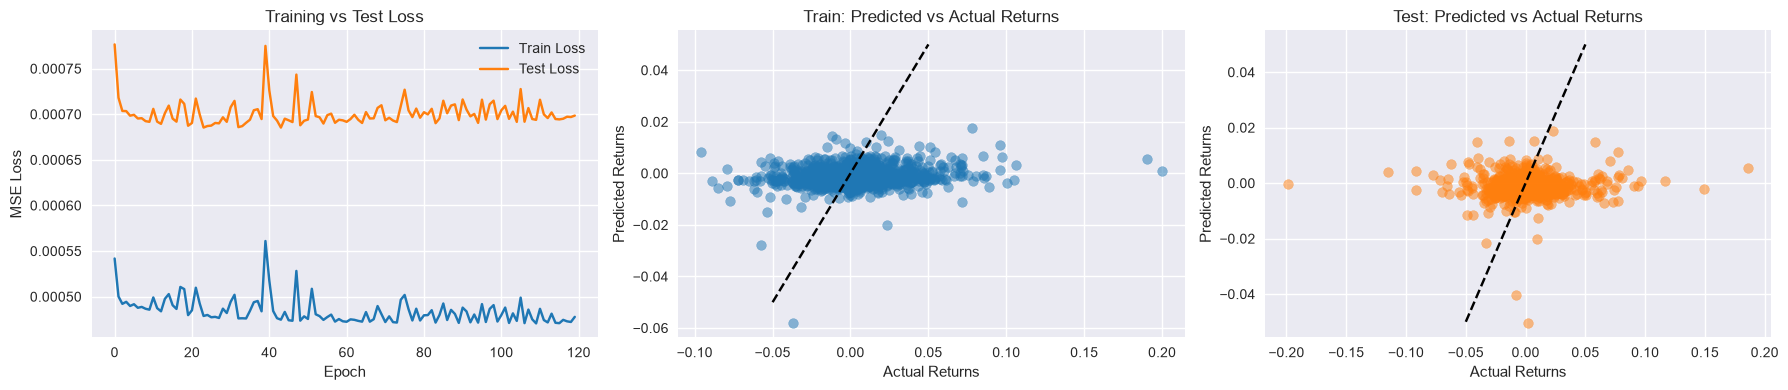

In [16]:
model.eval()
with torch.no_grad():
    train_pred = model(torch.tensor(X_train, dtype=torch.float32)).numpy()
    test_pred = model(torch.tensor(X_test, dtype=torch.float32)).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history['train'], label='Train Loss', color='tab:blue')
axes[0].plot(history['test'], label='Test Loss', color='tab:orange')
axes[0].set_title('Training vs Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].scatter(y_train, train_pred, alpha=0.5, color='tab:blue')
axes[1].plot([-0.05, 0.05], [-0.05, 0.05], color='black', linestyle='--')
axes[1].set_title('Train: Predicted vs Actual Returns')
axes[1].set_xlabel('Actual Returns')
axes[1].set_ylabel('Predicted Returns')

axes[2].scatter(y_test, test_pred, alpha=0.5, color='tab:orange')
axes[2].plot([-0.05, 0.05], [-0.05, 0.05], color='black', linestyle='--')
axes[2].set_title('Test: Predicted vs Actual Returns')
axes[2].set_xlabel('Actual Returns')
axes[2].set_ylabel('Predicted Returns')

plt.tight_layout()
plt.show()

## 9. Experiments

Try a few network configurations and compare their train/test losses.

In [17]:
experiment_configs = [
    {'epochs': 80, 'hidden_units': 16, 'hidden_layers': 1},
    {'epochs': 120, 'hidden_units': 32, 'hidden_layers': 2},
    {'epochs': 140, 'hidden_units': 64, 'hidden_layers': 2},
    {'epochs': 130, 'hidden_units': 32, 'hidden_layers': 3},
]

results = []
for config in experiment_configs:
    torch.manual_seed(0)
    model = DeepMLP(
        n_features=X_train.shape[1],
        hidden=config['hidden_units'],
        n_hidden_layers=config['hidden_layers'],
    )
    history = train_model_with_batches(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=config['epochs'],
        lr=1e-3,
        batch_size=32,
    )
    results.append({
        'config': f"epochs={config['epochs']}, hidden={config['hidden_units']}, layers={config['hidden_layers']}",
        'train_loss': history['train'][-1],
        'test_loss': history['test'][-1],
    })

comparison = pd.DataFrame(results)
comparison

,config,train_loss,test_loss
0,"epochs=80, hidden=16, layers=1",0.000481,0.000689
1,"epochs=120, hidden=32, layers=2",0.000478,0.000698
2,"epochs=140, hidden=64, layers=2",0.000477,0.000710
3,"epochs=130, hidden=32, layers=3",0.000466,0.000692


## 10. Debug Friendly Notes

Each stage is separated into its own cell so the notebook can be stepped through easily in VS Code Debug mode.

In [18]:
best_result = comparison.loc[comparison['test_loss'].idxmin()]
base_result = comparison.iloc[0]
improved = best_result['test_loss'] < base_result['test_loss']

conclusion = (
    f"The best configuration was {best_result['config']} with a test loss of {best_result['test_loss']:.4f}. "
    f"Compared with the first configuration ({base_result['config']}), the larger network {'did improve' if improved else 'did not improve'} test performance. "
    "In practice, a wider or deeper network can lower training loss while still failing to generalize better on the test period."
)
display(Markdown(conclusion))

The best configuration was epochs=80, hidden=16, layers=1 with a test loss of 0.0007. Compared with the first configuration (epochs=80, hidden=16, layers=1), the larger network did not improve test performance. In practice, a wider or deeper network can lower training loss while still failing to generalize better on the test period.